# **Part 1 — Data Loading & Validation**

In [ ]:
import csv

class InvalidRecordError(Exception):
    pass

def sales_data(sales):

  records = []

  with open("sales.csv") as file:
    content = csv.DictReader(file)
    for row in content:
      try:
        product = str(row["product"])
        quantity = int(row["quantity"])
        unit_price = float(row["unit_price"])
      except ValueError as error:
        print(f"Invalid record: {row} -{error}")
        continue

      try:
        if quantity < 0 or unit_price < 0:
            raise InvalidRecordError(f"Negative value: {row}")
      except InvalidRecordError as e:
       print(e)
       continue

      records.append({
        "product": product,
        "quantity": quantity,
        "unit_price": unit_price})

  return records

In [ ]:
# Sales Data
data = sales_data("sales.csv")
for r in data:
  print(r)

Invalid record: {'product': 'Wireless Charger', 'quantity': '', 'unit_price': '15.50'} -invalid literal for int() with base 10: ''
Invalid record: {'product': 'Gaming Headset', 'quantity': 'five', 'unit_price': '55.00'} -invalid literal for int() with base 10: 'five'
Negative value: {'product': 'Bluetooth Speaker', 'quantity': '-5', 'unit_price': '45.00'}
Negative value: {'product': 'Smart Watch Band', 'quantity': '14', 'unit_price': '-8.50'}
Invalid record: {'product': 'Cable Organizer', 'quantity': '', 'unit_price': '6.10'} -invalid literal for int() with base 10: ''
{'product': 'Wireless Mouse', 'quantity': 25, 'unit_price': 12.5}
{'product': 'Bluetooth Speaker', 'quantity': 10, 'unit_price': 45.0}
{'product': 'USB-C Cable', 'quantity': 60, 'unit_price': 5.99}
{'product': 'Laptop Stand', 'quantity': 15, 'unit_price': 22.75}
{'product': 'Mechanical Keyboard', 'quantity': 8, 'unit_price': 68.0}
{'product': 'Webcam HD', 'quantity': 12, 'unit_price': 34.99}
{'product': 'Desk Lamp', 'qua

In [ ]:
# Total number of valid records

print(f"Valid records: {len(data)}")

Valid records: 20


# **Part 2 — Data Processing**

In [ ]:
def total_revenue(records):

  total = 0

  for r in records:
    total += r["quantity"] * r["unit_price"]
  return total
print("Total revenue:", round(total_revenue(data),2))

Total revenue: 7334.8


In [ ]:
def top_product(records):
  revenue_by_product = {}

  for r in records:
        revenue = r["quantity"] * r["unit_price"]
        product = r["product"]
        revenue_by_product[product] = revenue_by_product.get(product, 0) + revenue

  top = max(revenue_by_product, key=revenue_by_product.get)
  return top

print("Top product:", top)

Top product: Wireless Earbuds


In [ ]:
running = True
while running:
    choice = input("Choose the option: ")

    if choice == "1":
         print(f"Total Revenue: {round(total_revenue(records), 2)}")
    elif choice == "2":
        print(f"Top Product: {top_product(records)}")
    elif choice == "3":
        print("Exit")
        running = False
    else:
        print("Invalid option. Try Again")

Choose the option: 1
Total Revenue: 7334.8
Choose the option: 2
Top Product: Wireless Earbuds
Choose the option: 2
Top Product: Wireless Earbuds
Choose the option: 3
Exit


# **Part 3- Analysis**

In [ ]:
import numpy as np

In [ ]:
def revenue_stats(records):
  revenue_array = np.array([r["quantity"] * r["unit_price"] for r in records])
  total = round(revenue_array.sum(), 2)
  average = round(revenue_array.mean(), 2)
  std_dev = round(revenue_array.std(), 2)
  return total, average, std_dev

total, average, std_dev = revenue_stats(data)
print(f'Total revenue: {total}')
print(f'Average revenue per product: {average}')
print(f'Standard deviation: {std_dev}')

Total revenue: 7334.8
Average revenue per product: 366.74
Standard deviation: 115.97


# **Part 4 — Visualization**

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
revenue_by_product = {}
for r in records:
    revenue = r["quantity"] * r["unit_price"]
    product = r["product"]
    revenue_by_product[product] = revenue_by_product.get(product, 0) + revenue

products = list(revenue_by_product.keys())
revenues = list(revenue_by_product.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(products, revenues, color="#191970", label="Revenue")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("sales_summary.png")
plt.show()

In [ ]:
def plot_revenue_by_product(records):
    revenue_by_product = {}
    for r in records:
        revenue = r["quantity"] * r["unit_price"]
        product = r["product"]
        revenue_by_product[product] = revenue_by_product.get(product, 0) + revenue

    products = list(revenue_by_product.keys())
    revenues = list(revenue_by_product.values())

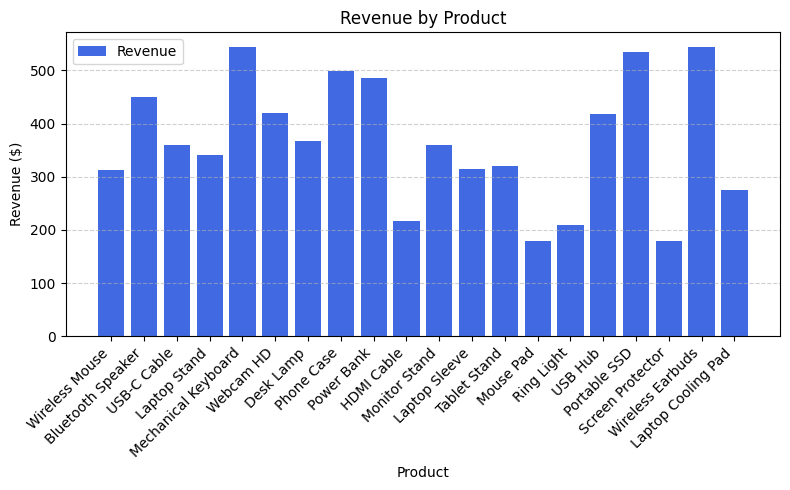

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(products, revenues, color="#4169E1", label="Revenue")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("revenue_bar_chart.png")
plt.show()

# **Part 5 — Menu-Driven Interface**

In [ ]:
running = True
while running:
          choice = input("Choose an option: ")

          if choice == "1":
              print(f"Total revenue: {total}")
              print(f"Average revenue per product: {average}")
              print(f"Standard deviation: {std_dev}")
          elif choice == "2":
              print(f"Top product: {top_product(records)}")
          elif choice == "3":
              plot_revenue_by_product(records)
              print("Chart saved as sales_summary")
          elif choice == "4":
              print("Exit")
              running = False
          else:
              print("Invalid choice, try again")

Choose an option: 1
Total revenue: 7334.8
Average revenue per product: 366.74
Standard deviation: 115.97
Choose an option: 2
Top product: Wireless Earbuds
Choose an option: 3
Chart saved as sales_summary
Choose an option: 4
Exit
